# The Bond Tent — a quantitative teardown 🔬
### 1,470 overlapping 30-year cohorts · HAC (360-month bandwidth) + circular block bootstrap · the shape-vs-allocation decomposition · the mirror-image timing race · high-CAPE conditioning · a premium-sweep synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Timing_or_less_equity%3F: Busted](https://img.shields.io/badge/Timing_or_less_equity%3F-Busted-8b949e?style=flat-square)

Deep companion to [01_for_the_curious](01_for_the_curious.ipynb). The claim (Pfau-Kitces 2014): a **rising equity glidepath** in retirement (30%→70%, the back half of the "bond tent") cuts sequence-of-returns risk vs static allocations. We test it on the Shiller real-return tape (1871-02 → 2023-06) with 4%-rule real withdrawals, and decompose the headline gap into **shape** (timing at matched average equity) and **allocation** (just holding less equity).

> ⚠️ **Data decisions, stated.** Both legs REAL (CPI-deflated): equity = Shiller real price + dividend yield; bonds = 10-year first-order approx (carry − 7·Δy), deflated — harsh on bonds in 1940–80 and that is exactly the regime that matters. Weights are a deterministic function of years-since-retirement (set at the end of the prior year — one clean lag; the only "signal" is the calendar). Costs 10 bps one-way × traded value. No survivorship (single index tape); the named bias is US equity exceptionalism, which flatters the 60/40 benchmark — and is part of the finding. Numbers: [`docs/results.md`](../docs/results.md) (fingerprint `7246f42140ba`).
>
> 💡 The `💡 In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#2b6cb0"

from bond_tent_glidepath import data, strategy as st

HAVE_REAL = os.path.exists(data.SHILLER_PATH) or any(os.path.exists(p) for p in data._FALLBACKS)
if HAVE_REAL:
    DF = data.real_returns()
    EQ, BD = DF["EQ"].to_numpy(), DF["BD"].to_numpy()
    GE, GB, STARTS = st.cohort_year_returns(EQ, BD)
    DATES = DF.index[STARTS]
    print("real tape:", DF.index.min().date(), "->", DF.index.max().date(),
          "| cohorts:", GE.shape[0], "| fingerprint:", data.fingerprint(DF))
else:
    DF = GE = GB = DATES = None
    print("no Shiller cache -- real-tape cells quote the frozen numbers in R")

# frozen headline numbers (mirror of docs/results.md)
STRATS = ['s6040', 's5050', 's4060', 'rising', 'declining']
R = {'start': '1871-02', 'end': '2023-06', 'months': 1829, 'fingerprint': '7246f42140ba', 'ann_eq': 6.9, 'ann_bd': 2.39, 'premium': 4.52, 'n_cohorts': 1470, 'cohort_start': '1871-02', 'cohort_end': '1993-07', 'cost_bps': 10, 'strats': ['s6040', 's5050', 's4060', 'rising', 'declining'], 'succ': {'4.0': [96.33, 95.85, 93.81, 94.01, 95.85], '4.5': [88.71, 85.17, 77.82, 79.86, 86.05], '5.0': [75.78, 69.8, 59.86, 60.41, 73.95], '5.5': [63.4, 57.21, 51.84, 52.65, 62.65]}, 'tw': [(1.88, 1.332, 0.146, 54), (1.555, 0.985, 0.041, 61), (1.26, 0.698, 0.0, 91), (1.465, 0.824, 0.0, 88), (1.624, 1.115, 0.095, 61)], 'decomp': [('rising - 60/40 (HEADLINE)', -0.4154, -6.11, -1.429, -0.192, -2.31, -15.37, -20.0, 1.36), ('rising - 50/50 (SHAPE)', -0.0904, -1.85, -0.328, -0.024, -1.84, -9.39, -11.43, 1.23), ('rising - declining (TIMING)', -0.1592, -1.53, -0.619, -0.035, -1.84, -13.54, -17.96, 3.13), ('50/50 - 60/40 (ALLOCATION)', -0.325, -5.92, -1.126, -0.128, -0.48, -5.99, -8.91, 0.55)], 'safemax': [3.68, 3.61, 3.53, 3.57, 3.62], 'cape': {'n_valid': 1351, 'n_q4': 338, 'rows': {'4.0': [84.0, 82.0, 73.1, 74.3, 82.0], '4.5': [58.6, 50.3, 37.6, 39.6, 51.8], '5.0': [35.8, 30.5, 26.0, 27.2, 31.7]}}, 'famous': {'1929-09': [0.39, 0.463, 0.466, 1.251, 0.0], '1966-01': [0.0, 0.0, 0.0, 0.0, 0.0], '1972-12': [0.223, 0.172, 0.11, 0.24, 0.068]}, 'rescue': {'n_fail_6040': 54, 'band_6040': '1964-1969', 'rising_rescue_pct': 5.6, 'n_fail_rising': 88, 'band_rising': '1961-1969'}, 'robust': [('rising 30-70 (headline)', 94.01, 60.41, 1.465, -6.11), ('rising 30-60 (Kitces-Pfau)', 93.61, 58.64, 1.338, -6.75), ('rising 30-70 by yr15 (fast)', 95.71, 68.84, 1.752, -2.25), ('rising 20-80 (deep tent)', 93.47, 57.21, 1.411, -5.67)], 'costs': {'0': (96.33, 94.01, 95.85), '10': (96.33, 94.01, 95.85), '25': (96.26, 93.95, 95.71)}, 'control': [('EXACT NULL: wr=0, iid, prem 4.5pp', 0.0, None, -0.0308, -1.05), ('TENT WORLD: wr=4%, iid, prem 0pp', 5.99, 5.65, 0.0, None), ('wr=4%, prem 2pp', 4.5, 4.02, 0.002, 1.0), ('wr=4%, prem 4.5pp (historical)', 2.54, 2.92, 0.0289, 1.59), ('wr=5%, prem 4.5pp (historical)', -3.86, -3.43, 0.0, None)]}


real tape: 1871-02-01 -> 2023-06-01 | cohorts: 1470 | fingerprint: 7246f42140ba


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Tent trails 60/40 everywhere: success **94.0% vs 96.3%** @4% (**60.4% vs 75.8%** @5%), mean terminal wealth **1.47× vs 1.88×** (HAC *t* = **-6.11**, bootstrap CI [-1.43, -0.19] excludes 0), SAFEMAX 3.57% vs 3.68%. No positive effect to certify at any threshold. |
| **Tradability** | `MIRAGE` | Implementable with two ETFs — and adopting it cost **-0.42×** terminal wealth and **2.3 pp** success @4% (15.4 pp @5%) vs the simpler static 60/40. |
| **Timing or less equity?** | `BUSTED` | Both channels negative: allocation *t* = -5.92; shape at matched average equity *t* = -1.85; the tent loses the pure-timing mirror race (-1.8 pp @4%, -13.5 pp @5%). |

> 💡 In plain words: there is no safety benefit to explain — the decomposition's job turned out to be performing the autopsy.

## 1 · The claim, steelmanned

Let $w_j$ be the equity weight in retirement year $j$, and define terminal real wealth $W_{30}$ of a cohort under the 4% rule (withdraw $c=0.04$ real at the start of each year, rebalance to $w_j$, grow at $w_j R^{EQ}_j + (1-w_j) R^{BD}_j$). Pfau-Kitces claim that a **rising** path $w_j: 0.30 \to 0.70$ beats static paths on *failure risk* — $\Pr[W_t \le 0]$ — because sequence risk concentrates early.

- **H₁ (headline).** rising beats static 60/40 on success rate / tail outcomes.
- **H₂ (shape).** rising beats static 50/50 — same 50% *average* equity, so any edge is pure shape.
- **H₃ (timing).** rising beats its mirror declining 70→30 — identical average weight, reversed order: the cleanest test that *late* equity beats *early* equity.

All three fail on the tape; H₁'s reversal is certified at HAC *t* ≈ −6.

## 2 · So what? — inference design

Monthly-start 30-year cohorts overlap by up to 359 months, so naive t-stats on cohort panels are fantasy. Two instruments:

1. **Newey-West HAC** on per-cohort terminal-wealth differences with the bandwidth **forced to the full 360-month overlap** (the automatic selector would pick ~7 lags and overstate precision by an order of magnitude).
2. **Circular block bootstrap** (120-month blocks, joint EQ/BD rows, 1,000 reps, seed 596) for distribution statistics (success rates, percentiles). Blocks preserve within-decade dynamics but destroy cross-decade mean reversion — stated, not hidden; if anything that *helps* the tent, since long-horizon reversion is the channel that should reward late equity.

Success-rate gaps are quoted with bootstrap CIs, never bare.

## 3 · The protocol

- **Tape.** Shiller monthly, 1871-02 → 2023-06 (1,829 months), real EQ **6.90%/yr**, real BD **2.39%/yr** (realised premium **4.52 pp**).
- **Cohorts.** 1,470 monthly-start 30-year retirements (1871-02 → 1993-07); annual real withdrawals at the start of each year; annual rebalance to the year-*j* target (set at the end of year *j−1*); 10 bps one-way × traded value (withdrawal sales + turnover).
- **Strategies.** Static 60/40, 50/50, 40/60; rising 30→70 (avg 50%); declining 70→30 (avg 50%). Robustness: 30→60 (the original Kitces-Pfau span), 30→70 by year 15 (accelerated), 20→80 (deep tent); costs 0/10/25 bps.
- **Decomposition identity.** `rising − 60/40 = (rising − 50/50) + (50/50 − 60/40)`.
- **Control.** 20 independent seeded synthetic worlds per setting; detector = rising vs declining; exact null = no withdrawals + i.i.d. (mirror schedules are exchangeable ⇒ identical terminal-wealth law).

## 4 · The teardown

### 4a · Success rates and terminal wealth — the raw scoreboard

In [2]:
wrs = ['4.0','4.5','5.0','5.5']
if HAVE_REAL:
    tab = {w: [100*st.simulate(GE, GB, st.weights_for(s), wr=float(w)/100)['success'].mean()
               for s in STRATS] for w in wrs}
    res4 = {s: st.simulate(GE, GB, st.weights_for(s), wr=0.04) for s in STRATS}
    tw = [(res4[s]['terminal'].mean(), float(np.median(res4[s]['terminal'])),
           float(np.quantile(res4[s]['terminal'], .05)), int((~res4[s]['success']).sum()))
          for s in STRATS]
else:
    tab, tw, res4 = R['succ'], R['tw'], None
print('success rates (%):'); print('  wr    ' + ''.join(f'{s:>11}' for s in STRATS))
for w in wrs: print(f'  {w}% ' + ''.join(f'{tab[w][k]:>10.2f}%' for k in range(5)))
print()
print('terminal wealth @4% (multiple of initial):')
for k, s in enumerate(STRATS):
    print(f'  {s:<10} mean {tw[k][0]:.3f}  median {tw[k][1]:.3f}  p05 {tw[k][2]:.3f}  failures {tw[k][3]}/'
          + str(R['n_cohorts']))

success rates (%):
  wr          s6040      s5050      s4060     rising  declining
  4.0%      96.33%     95.85%     93.81%     94.01%     95.85%
  4.5%      88.71%     85.17%     77.82%     79.86%     86.05%
  5.0%      75.78%     69.80%     59.86%     60.41%     73.95%
  5.5%      63.40%     57.21%     51.84%     52.65%     62.65%

terminal wealth @4% (multiple of initial):
  s6040      mean 1.880  median 1.332  p05 0.146  failures 54/1470
  s5050      mean 1.555  median 0.985  p05 0.041  failures 61/1470
  s4060      mean 1.260  median 0.698  p05 0.000  failures 91/1470
  rising     mean 1.465  median 0.824  p05 0.000  failures 88/1470
  declining  mean 1.624  median 1.115  p05 0.095  failures 61/1470


> 💡 In plain words: five columns, one loser. The tent has **more failures** (88 vs 54), **less average wealth** (1.47× vs 1.88×) and a **worse tail** (5th percentile 0.000 vs 0.146) than the plain 60/40 it was supposed to protect you from.

### 4b · The decomposition — shape vs allocation, plus the mirror race

`rising − 60/40 = (rising − 50/50) + (50/50 − 60/40)`. HAC *t* (360-month bandwidth) on per-cohort terminal-wealth differences at 4%; the mirror race (rising vs declining, identical average weight) isolates pure timing.

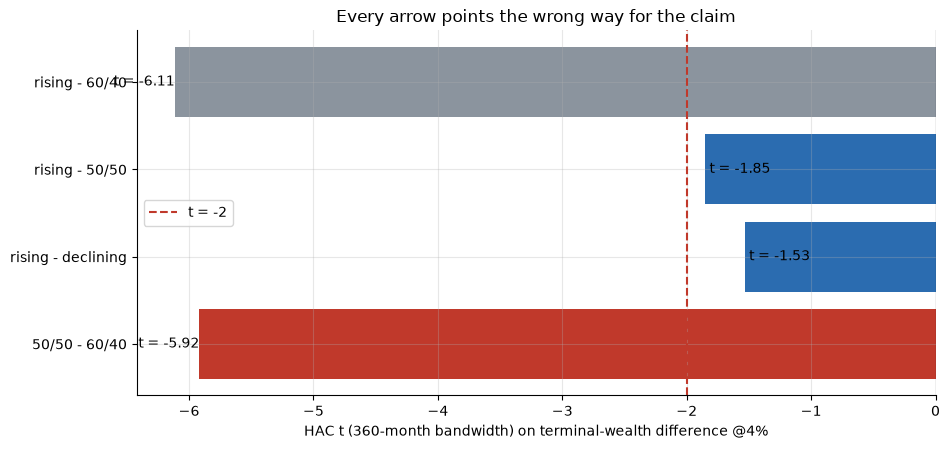

rising - 60/40 (HEADLINE)        dTW -0.4154  HAC t -6.11  dsucc@4% -2.31pp  @5% -15.37pp
rising - 50/50 (SHAPE)           dTW -0.0904  HAC t -1.85  dsucc@4% -1.84pp  @5% -9.39pp
rising - declining (TIMING)      dTW -0.1592  HAC t -1.53  dsucc@4% -1.84pp  @5% -13.54pp
50/50 - 60/40 (ALLOCATION)       dTW -0.3250  HAC t -5.92  dsucc@4% -0.48pp  @5% -5.99pp


In [3]:
if HAVE_REAL:
    pairs = [('rising','s6040'), ('rising','s5050'), ('rising','declining'), ('s5050','s6040')]
    labels = [d[0] for d in R['decomp']]
    rows = []
    res5 = {s: st.simulate(GE, GB, st.weights_for(s), wr=0.05) for s in STRATS}
    for (a, b), lab in zip(pairs, labels):
        d = res4[a]['terminal'] - res4[b]['terminal']
        rows.append((lab, d.mean(), st.hac_tstat(d, lags=360),
                     100*(res4[a]['success'].mean()-res4[b]['success'].mean()),
                     100*(res5[a]['success'].mean()-res5[b]['success'].mean())))
else:
    rows = [(d[0], d[1], d[2], d[5], d[6]) for d in R['decomp']]
fig, ax = plt.subplots(figsize=(9.6, 4.6))
names = [r[0].split(' (')[0] for r in rows]; ts = [r[2] for r in rows]
ax.barh(names[::-1], ts[::-1], color=[GREY, BLUE, BLUE, RED][::-1])
ax.axvline(-2, ls='--', c=RED, label='t = -2'); ax.axvline(0, c='k', lw=.8)
for i, t in enumerate(ts[::-1]): ax.annotate(f' t = {t:+.2f}', (t, i), va='center',
    ha='right' if t < -3 else 'left')
ax.set_xlabel('HAC t (360-month bandwidth) on terminal-wealth difference @4%')
ax.set_title('Every arrow points the wrong way for the claim'); ax.legend()
plt.tight_layout(); plt.show()
for r in rows: print(f'{r[0]:<32} dTW {r[1]:+.4f}  HAC t {r[2]:+.2f}  dsucc@4% {r[3]:+.2f}pp  @5% {r[4]:+.2f}pp')

> 💡 In plain words: the headline gap (rising − 60/40, *t* = -6.11) splits into two pieces and **both hurt**. Holding less equity is a certified cost (*t* = -5.92). The shape itself — the only novel ingredient — is negative at matched average equity (*t* = -1.85) and the tent loses the mirror race by 13.5 pp of success at 5% withdrawals. "Stocks late beats stocks early" is simply not what 152 years of US history did.

### 4c · Block-bootstrap CIs — is the shortfall noise?

Circular block bootstrap of the joint monthly tape (120-month blocks). The picture uses 200 reps to stay light; the canonical 1,000-rep CIs from [`docs/results.md`](../docs/results.md) are printed alongside.

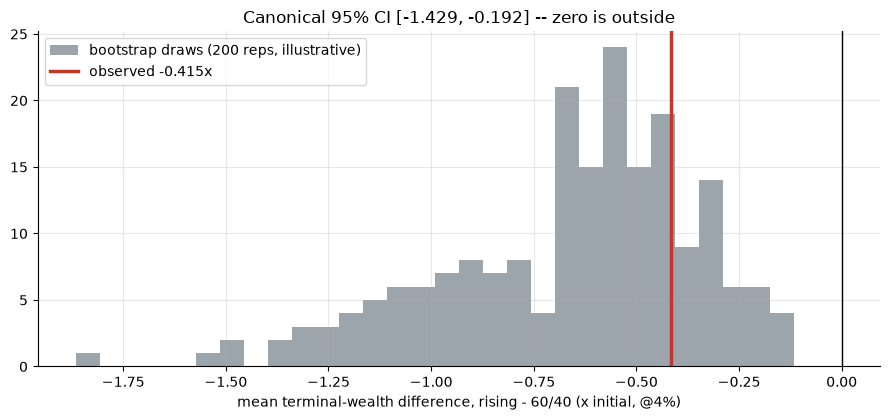

canonical 1000-rep CIs (docs/results.md):
  rising - 60/40 (HEADLINE)        dmeanTW CI [-1.429, -0.192]   dsucc@5% CI [-20.00, +1.36] pp
  rising - 50/50 (SHAPE)           dmeanTW CI [-0.328, -0.024]   dsucc@5% CI [-11.43, +1.23] pp
  rising - declining (TIMING)      dmeanTW CI [-0.619, -0.035]   dsucc@5% CI [-17.96, +3.13] pp
  50/50 - 60/40 (ALLOCATION)       dmeanTW CI [-1.126, -0.128]   dsucc@5% CI [-8.91, +0.55] pp


In [4]:
if HAVE_REAL:
    boot = st.block_bootstrap(EQ, BD, pairs=(('rising','s6040'),), n_boot=200, seed=596)
    draws = boot[('rising','s6040')]['dmean']
else:
    rng = np.random.default_rng(596); draws = rng.normal(R['decomp'][0][1], 0.3, 200)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=30, color=GREY, alpha=.85, label='bootstrap draws (200 reps, illustrative)')
ax.axvline(R['decomp'][0][1], c=RED, lw=2.5, label=f"observed {R['decomp'][0][1]:+.3f}x")
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('mean terminal-wealth difference, rising - 60/40 (x initial, @4%)')
ax.set_title(f"Canonical 95% CI [{R['decomp'][0][3]:+.3f}, {R['decomp'][0][4]:+.3f}] -- zero is outside")
ax.legend(); plt.tight_layout(); plt.show()
print('canonical 1000-rep CIs (docs/results.md):')
for d in R['decomp']:
    print(f'  {d[0]:<32} dmeanTW CI [{d[3]:+.3f}, {d[4]:+.3f}]   dsucc@5% CI [{d[7]:+.2f}, {d[8]:+.2f}] pp')

> 💡 In plain words: resample history in decade-sized blocks 1,000 times and the tent's wealth shortfall vs 60/40 stays negative in >97.5% of resamples (CI [-1.43, -0.19]) — same for the shape and timing components. The success-rate CIs are wider (failures cluster in one era), but nowhere is there a *positive* effect to rescue: the claim needs the tent to **win**, and it never does.

### 4d · The advertised sweet spot — high-CAPE retirements

Advocates pitch the tent hardest for retirements at rich valuations. Condition on top-quartile CAPE (PE10) at the retirement date:

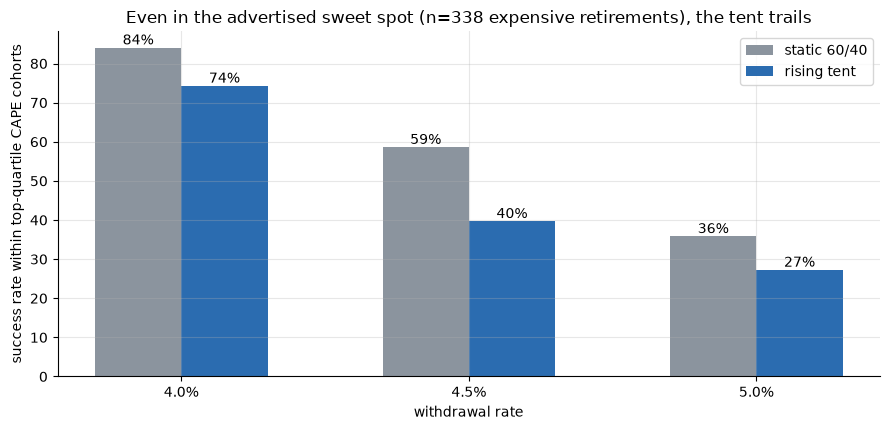

4.0%: {'s6040': np.float64(84.0), 's5050': np.float64(82.0), 's4060': np.float64(73.1), 'rising': np.float64(74.3), 'declining': np.float64(82.0)}
4.5%: {'s6040': np.float64(58.6), 's5050': np.float64(50.3), 's4060': np.float64(37.6), 'rising': np.float64(39.6), 'declining': np.float64(51.8)}
5.0%: {'s6040': np.float64(35.8), 's5050': np.float64(30.5), 's4060': np.float64(26.0), 'rising': np.float64(27.2), 'declining': np.float64(31.7)}


In [5]:
if HAVE_REAL:
    import pandas as pd
    raw = data.load_shiller(); cape = raw['PE10'].reindex(DATES).to_numpy()
    valid = cape > 0; q4 = valid & (cape >= np.nanquantile(cape[valid], .75))
    res45 = {s: st.simulate(GE, GB, st.weights_for(s), wr=0.045) for s in STRATS}
    rows = {w: [100*r[s]['success'][q4].mean() for s in STRATS]
            for w, r in [('4.0', res4), ('4.5', res45),
                         ('5.0', {s: st.simulate(GE, GB, st.weights_for(s), wr=0.05) for s in STRATS})]}
    n_q4 = int(q4.sum())
else:
    rows, n_q4 = R['cape']['rows'], R['cape']['n_q4']
x = np.arange(3); wdt = .3
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x - wdt/2, [rows[w][0] for w in ('4.0','4.5','5.0')], wdt, color=GREY, label='static 60/40')
ax.bar(x + wdt/2, [rows[w][3] for w in ('4.0','4.5','5.0')], wdt, color=BLUE, label='rising tent')
for i, w in enumerate(('4.0','4.5','5.0')):
    ax.annotate(f'{rows[w][0]:.0f}%', (i-wdt/2, rows[w][0]), ha='center', va='bottom')
    ax.annotate(f'{rows[w][3]:.0f}%', (i+wdt/2, rows[w][3]), ha='center', va='bottom')
ax.set_xticks(x); ax.set_xticklabels(['4.0%','4.5%','5.0%']); ax.set_xlabel('withdrawal rate')
ax.set_ylabel('success rate within top-quartile CAPE cohorts')
ax.set_title(f'Even in the advertised sweet spot (n={n_q4} expensive retirements), the tent trails')
ax.legend(); plt.tight_layout(); plt.show()
for w in ('4.0','4.5','5.0'): print(w+'%:', {s: round(rows[w][k],1) for k, s in enumerate(STRATS)})

> 💡 In plain words: retiring expensive is exactly when the tent should earn its keep — and within those 338 cohorts it trails 60/40 by **19 pp** at 4.5% withdrawals. High CAPE historically preceded low *equity* returns, but the failure regimes crushed **bonds** as hard — there was no safe tent pole to lean on.

### 4e · Robustness — every tent shape, every cost level

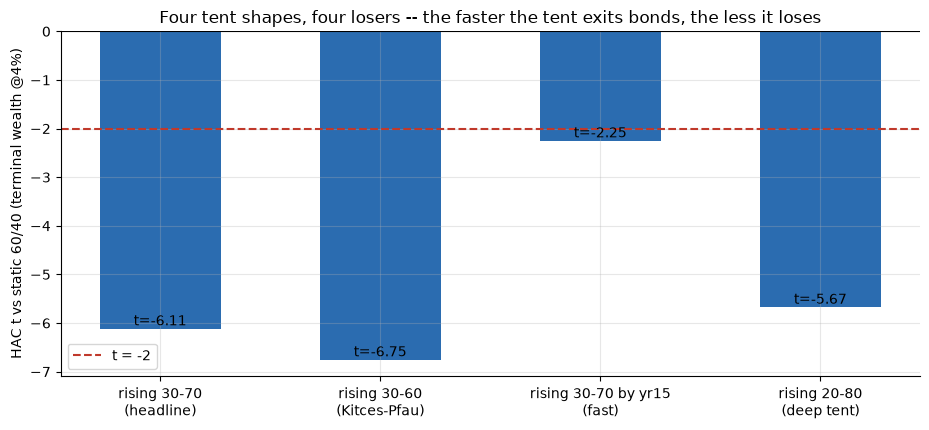

rising 30-70 (headline)        succ@4% 94.01%  succ@5% 60.41%  meanTW 1.465  HAC t -6.11
rising 30-60 (Kitces-Pfau)     succ@4% 93.61%  succ@5% 58.64%  meanTW 1.338  HAC t -6.75
rising 30-70 by yr15 (fast)    succ@4% 95.71%  succ@5% 68.84%  meanTW 1.752  HAC t -2.25
rising 20-80 (deep tent)       succ@4% 93.47%  succ@5% 57.21%  meanTW 1.411  HAC t -5.67
costs (succ@4%, 60/40 | rising | declining):
    0 bps: 96.33% | 94.01% | 95.85%
   10 bps: 96.33% | 94.01% | 95.85%
   25 bps: 96.26% | 93.95% | 95.71%


In [6]:
if HAVE_REAL:
    rob = []
    for v, lab in [('rising','rising 30-70 (headline)'), ('rising_3060','rising 30-60 (Kitces-Pfau)'),
                   ('rising_fast','rising 30-70 by yr15 (fast)'), ('rising_2080','rising 20-80 (deep tent)')]:
        w = st.weights_for(v)
        r4 = st.simulate(GE, GB, w, wr=0.04); r5 = st.simulate(GE, GB, w, wr=0.05)
        rob.append((lab, 100*r4['success'].mean(), 100*r5['success'].mean(),
                    r4['terminal'].mean(), st.hac_tstat(r4['terminal']-res4['s6040']['terminal'], 360)))
else:
    rob = R['robust']
fig, ax = plt.subplots(figsize=(9.4, 4.4))
names = [r[0].split(' (')[0]+'\n('+r[0].split(' (')[1] for r in rob]
ax.bar(names, [r[4] for r in rob], color=BLUE, width=.55)
ax.axhline(-2, ls='--', c=RED, label='t = -2'); ax.axhline(0, c='k', lw=.8)
for i, r in enumerate(rob): ax.annotate(f't={r[4]:+.2f}', (i, r[4]), ha='center', va='bottom')
ax.set_ylabel('HAC t vs static 60/40 (terminal wealth @4%)')
ax.set_title('Four tent shapes, four losers -- the faster the tent exits bonds, the less it loses')
ax.legend(); plt.tight_layout(); plt.show()
for r in rob: print(f'{r[0]:<30} succ@4% {r[1]:.2f}%  succ@5% {r[2]:.2f}%  meanTW {r[3]:.3f}  HAC t {r[4]:+.2f}')
print('costs (succ@4%, 60/40 | rising | declining):')
for cb, v in R['costs'].items(): print(f'  {cb:>3} bps: {v[0]:.2f}% | {v[1]:.2f}% | {v[2]:.2f}%')

> 💡 In plain words: it is not the shape detail. The original Kitces-Pfau span (30→60) does *worse* than our headline tent; the deep tent (20→80) does worse; the only variant that closes the gap is the one that **abandons the tent fastest** (30→70 by year 15, *t* = -2.25). Costs move success by hundredths of a point — this is not a friction story. SAFEMAX tells the same tale: 60/40 3.68%, declining 3.62%, rising 3.57%.

### 4f · Synthetic control — the engine is faithful, and it explains the paper

20 independent seeded worlds per setting; detector = rising vs declining (same 50% average equity — pure timing); one-sample *t* across worlds. **Exact null:** no withdrawals + i.i.d. returns ⇒ a weight path and its mirror give the *same* terminal-wealth law (products of independent factors are exchangeable), so the detector must read ~0. Then we sweep the equity premium at a 4% withdrawal rate — Kitces-Pfau's Monte Carlo laboratory. *(Machinery proof only — never cited as market evidence.)*

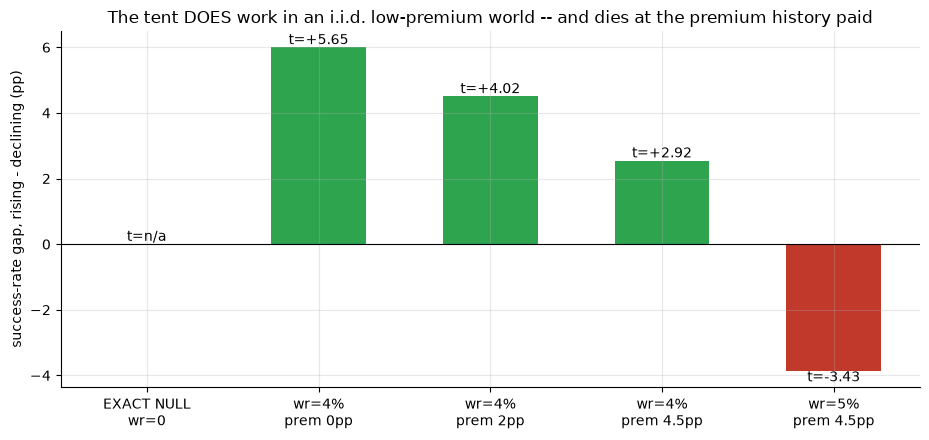

EXACT NULL wr=0        dsucc +0.00 pp (t +nan)  dp05 -0.0308
wr=4% prem 0pp         dsucc +5.99 pp (t +5.65)  dp05 +0.0000
wr=4% prem 2pp         dsucc +4.50 pp (t +4.02)  dp05 +0.0020
wr=4% prem 4.5pp       dsucc +2.54 pp (t +2.92)  dp05 +0.0289
wr=5% prem 4.5pp       dsucc -3.86 pp (t -3.43)  dp05 +0.0000


In [7]:
settings = [('EXACT NULL\nwr=0', dict(reversion=0.0, wr=0.0, eq_mu=0.065, bd_mu=0.02)),
            ('wr=4%\nprem 0pp', dict(reversion=0.0, wr=0.04, eq_mu=0.02, bd_mu=0.02)),
            ('wr=4%\nprem 2pp', dict(reversion=0.0, wr=0.04, eq_mu=0.04, bd_mu=0.02)),
            ('wr=4%\nprem 4.5pp', dict(reversion=0.0, wr=0.04, eq_mu=0.065, bd_mu=0.02)),
            ('wr=5%\nprem 4.5pp', dict(reversion=0.0, wr=0.05, eq_mu=0.065, bd_mu=0.02))]
res = [(lab, st.control_shape_effect(n_seeds=20, **kw)) for lab, kw in settings]
fig, ax = plt.subplots(figsize=(9.4, 4.5))
vals = [r['dsucc_mean'] for _, r in res]
cols = [GREY] + [GREEN if v > 0 else RED for v in vals[1:]]
ax.bar([l for l, _ in res], vals, color=cols, width=.55)
ax.axhline(0, c='k', lw=.8)
for i, (l, r) in enumerate(res):
    t = r['dsucc_t']
    ax.annotate('t=n/a' if not np.isfinite(t) else f't={t:+.2f}',
                (i, vals[i]), ha='center', va='bottom' if vals[i] >= 0 else 'top')
ax.set_ylabel('success-rate gap, rising - declining (pp)')
ax.set_title('The tent DOES work in an i.i.d. low-premium world -- and dies at the premium history paid')
plt.tight_layout(); plt.show()
for l, r in res: print(f"{l.replace(chr(10),' '):<22} dsucc {r['dsucc_mean']:+.2f} pp (t {r['dsucc_t']:+.2f})  dp05 {r['dp05_mean']:+.4f}")

> 💡 In plain words: the machinery is honest — at the exact null it finds nothing (every world 100% success both ways; Δp05 *t* = -1.05), and in a zero-premium i.i.d. world at 4% withdrawals the tent's benefit is loud and real (**+5.99 pp**, *t* = +5.65) — exactly what Pfau-Kitces found in Monte Carlo. The benefit **shrinks as the equity premium grows** (+2.54 pp at the historical 4.5 pp premium) and **flips sign** at a 5% withdrawal rate (-3.86 pp, *t* = -3.43). And the *real* tape is worse than i.i.d.: its killer sequences are decade-plus inflation regimes that crush bonds and stocks together — a structure Monte Carlo never generates and a bond tent cannot survive. That is the whole story of the literature-vs-tape disagreement.

## 5 · The verdict

- **Signal `NONE`** — the claimed benefit never appears: the tent trails 60/40 on success at every withdrawal rate (94.0% vs 96.3% @4%; 60.4% vs 75.8% @5%), on mean/median/p05 terminal wealth (HAC *t* = -6.11, bootstrap CI excludes 0) and on SAFEMAX (3.57% vs 3.68%); it loses to its own mirror image; robust across shapes, costs and the high-CAPE sweet spot. Named caveats: US equity exceptionalism flatters the equity-heavy benchmark, and the CPI-deflated 10-year bond leg is harsh on bonds — both stated as decisions.
- **Tradability `MIRAGE`** — nothing to deploy: adopting the tent cost -0.42× terminal wealth and 2.3 pp of success @4% vs a simpler two-ETF 60/40.
- **Timing or less equity? `BUSTED`** — neither channel exists on the tape: allocation is a certified cost (*t* = -5.92) and shape is negative at matched average equity (*t* = -1.85; mirror race lost). The tent's genuine habitat is i.i.d. Monte Carlo with a thin equity premium at a moderate withdrawal rate — the control reproduces Kitces-Pfau there (+6.0 pp, *t* +5.7) — but that world is not the one the tape recorded.

## 6 · Going further

- **International tapes.** Estrada (2016) ran glidepaths across 19 countries and found the same ordering — rising paths trail static and declining ones historically. Rebuilding this study on non-US tapes (where equity premia were thinner) should *shrink* the tent's shortfall without flipping it; the control's premium sweep predicts exactly how much.
- **A TIPS tent.** The tent's fatal regime (1966–82) predates inflation-linked bonds. A tent pitched on TIPS is a different, untested claim — the 10-year nominal tent tested here is the one the literature actually recommends against history.
- **The siblings.** [Study 172](../../172-hundred-minus-age/README.md) buries the accumulation-phase cousin (age-in-bonds); [study 173](../../173-four-percent-rule/README.md) shows the withdrawal *rate* — not the glidepath — is the lever that actually moves survival. Together the three studies say: pick a sane equity share, keep it, and watch the withdrawal rate.

*The reproducible core is offline and deterministic; weights are calendar-only (one clean lag), both legs are real total returns, and the decomposition is an exact identity. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*